In [ ]:
# import things

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import set_global_policy
import tensorflow.keras.backend as K

In [ ]:
patch_size = 256  # Patch size for input data
patch_dir = 'dataset_patched'  # Directory where patches are stored

In [4]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [5]:
# Define U-Net
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

    # Downsampling path
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck layer
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)

    # Upsampling path
    u1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u1 = concatenate([u1, c3])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u1)

    u2 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c5)
    u2 = concatenate([u2, c2])
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)

    u3 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c6)
    u3 = concatenate([u3, c1])
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(u3)

    # Output layer with a sigmoid activation for binary classification
    outputs = Conv2D(1, (1, 1), activation='sigmoid', dtype='float32')(c7)

    # Compile the model with binary cross-entropy loss and the custom F1 metric
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', f1])
    model.summary()  # REQUIREMENT: Model summary must be visible
    return model

In [ ]:
# Build U-Net
model = simple_unet_model(patch_size, patch_size, 3)

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d_8 (Conv2D)           (None, 256, 256, 16)         448       ['input_2[0][0]']             
                                                                                                  
 max_pooling2d_3 (MaxPoolin  (None, 128, 128, 16)         0         ['conv2d_8[0][0]']            
 g2D)                                                                                             
                                                                                                  
 conv2d_9 (Conv2D)           (None, 128, 128, 32)         4640      ['max_pooling2d_3[0][0]'

In [12]:
# Setup a generator for training
# ImageDataGenerator is used to load and preprocess training images.
train_image_gen = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    f'{patch_dir}/train_images',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='rgb',
    seed=42
)
train_mask_gen = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    f'{patch_dir}/train_masks',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',
    seed=42
)

# Combine image and mask generators for training
def combine_generators(image_gen, mask_gen):
    while True:
        yield next(image_gen), next(mask_gen)

train_gen = combine_generators(train_image_gen, train_mask_gen)

Found 39930 images belonging to 1 classes.
Found 39930 images belonging to 1 classes.


In [13]:
# Setup a generator for validation
val_image_gen = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    f'{patch_dir}/val_images',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='rgb',
    seed=42
)
val_mask_gen = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    f'{patch_dir}/val_masks',
    target_size=(patch_size, patch_size),
    batch_size=32,
    class_mode=None,
    color_mode='grayscale',
    seed=42
)

val_gen = combine_generators(val_image_gen, val_mask_gen)

Found 5445 images belonging to 1 classes.
Found 5445 images belonging to 1 classes.


In [14]:
# EarlyStopping()
from keras.callbacks import EarlyStopping
cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
# This is where the magic happens
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_image_gen),
    validation_data=val_gen,
    validation_steps=len(val_image_gen),
    epochs=50,
    callbacks=[cb]
)

Epoch 1/50


2025-01-16 23:55:19.923061: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-01-16 23:55:22.704555: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fb7bcd8edf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-16 23:55:22.704754: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-01-16 23:55:22.711096: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737071723.178142  126832 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1248/1248 [==============================] - 191s 143ms/step - loss: 0.0197 - accuracy: 0.9958 - f1: 0.4171 - val_loss: 0.0111 - val_accuracy: 0.9970 - val_f1: 0.3565
Epoch 2/50
1248/1248 [==============================] - 180s 144ms/step - loss: 0.0091 - accuracy: 0.9970 - f1: 0.6625 - val_loss: 0.0065 - val_accuracy: 0.9980 - val_f1: 0.6286
Epoch 3/50
1248/1248 [==============================] - 178s 143ms/step - loss: 0.0070 - accuracy: 0.9975 - f1: 0.7360 - val_loss: 0.0055 - val_accuracy: 0.9982 - val_f1: 0.7169
Epoch 4/50
1248/1248 [==============================] - 170s 136ms/step - loss: 0.0064 - accuracy: 0.9977 - f1: 0.7539 - val_loss: 0.0062 - val_accuracy: 0.9981 - val_f1: 0.6787
Epoch 5/50
1248/1248 [==============================] - 159s 128ms/step - loss: 0.0060 - accuracy: 0.9978 - f1: 0.7658 - val_loss: 0.0046 - val_accuracy: 0.9984 - val_f1: 0.7505
Epoch 6/50
1248/1248 [==============================] - 164s 131ms/step - loss: 0.0057 - accuracy: 0.9978 - f1: 0.7757 - 

In [ ]:
# Save the model

example_file_name = f'anastasiia_234301_unet_model_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

anastasiia_234301_unet_model_256px.h5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# REQUIREMENT: Run and display the output of this cell.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.003287318628281355
Best validation f1: 0.8196360468864441


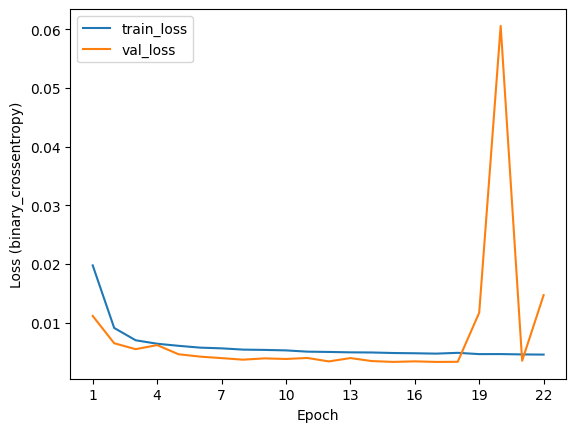

In [ ]:
# Plot training & validation loss values
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

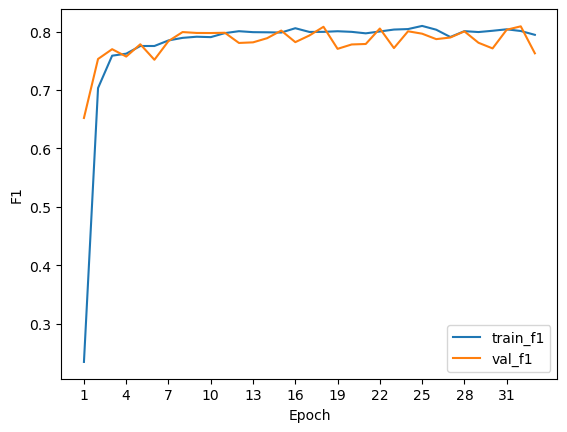

In [ ]:
# Plot training & validation f1 values
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))